# Spotify Data Analysis — Part 3: Data Visualization

20 SQL questions answered with charts and KPIs.

**Database:** `spotify_intel.db`
**Libraries:** `pandas`, `matplotlib`, `sqlite3`

In [1]:
import sqlite3
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import io
from IPython.display import SVG, display as _ipy_display

DB_PATH = "spotify_intel.db"

def q(sql):
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql_query(sql, conn)

# SVG rendering — fixes Hebrew BiDi text in bar charts
matplotlib.rcParams['svg.fonttype'] = 'none'

def _svg_show(*args, **kwargs):
    buf = io.BytesIO()
    plt.savefig(buf, format='svg', bbox_inches='tight')
    buf.seek(0)
    _ipy_display(SVG(buf.read()))
    plt.close()

plt.show = _svg_show

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'font.size': 11,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Segoe UI', 'Tahoma', 'Arial', 'DejaVu Sans'],
})

C1 = '#6c5ce7'
C2 = '#dfe6e9'
PALETTE = ['#6c5ce7','#a29bfe','#fd79a8','#fdcb6e','#00b894','#74b9ff','#e17055','#00cec9']

def kpi(value, label):
    fig, ax = plt.subplots(figsize=(4, 2.2))
    ax.text(0.5, 0.62, str(value), ha='center', va='center',
            fontsize=52, fontweight='bold', color=C1, transform=ax.transAxes)
    ax.text(0.5, 0.18, label, ha='center', va='center',
            fontsize=12, color='#636e72', transform=ax.transAxes)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

print("Setup complete — SVG rendering active (Hebrew text handled by SVG engine).")

Setup complete — SVG rendering active (Hebrew text handled by SVG engine).


---
## Q1 — How many unique songs are stored in the database in total?

,total_tracks
0,725


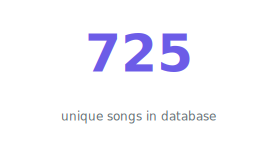

In [2]:
df = q("SELECT COUNT(id) AS total_tracks FROM tracks")
display(df)
kpi(df['total_tracks'][0], "unique songs in database")

---
## Q2 — How many liked songs do you have?

,liked_songs
0,636


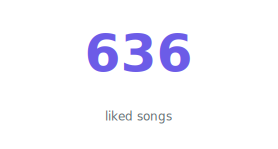

In [3]:
df = q("SELECT COUNT(*) AS liked_songs FROM listening_snapshot WHERE term = 'liked'")
display(df)
kpi(df['liked_songs'][0], "liked songs")

---
## Q3 — How many liked songs have lyrics, and what percentage is that?

,total_liked,with_lyrics,pct_with_lyrics
0,636,488,76.7


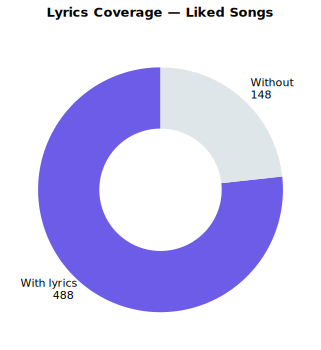

In [4]:
df = q("""
SELECT
    COUNT(*) AS total_liked,
    COUNT(tl.lyrics_raw) AS with_lyrics,
    ROUND(CAST(COUNT(tl.lyrics_raw) AS FLOAT) / COUNT(*) * 100, 1) AS pct_with_lyrics
FROM listening_snapshot ls
LEFT JOIN track_lyrics tl ON ls.track_id = tl.track_id
WHERE ls.term = 'liked'
""")
display(df)

total    = int(df['total_liked'][0])
with_lyr = int(df['with_lyrics'][0])
without  = total - with_lyr

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [with_lyr, without],
    labels=[f'With lyrics\n{with_lyr}', f'Without\n{without}'],
    colors=[C1, C2],
    startangle=90,
    wedgeprops=dict(width=0.5),
    textprops=dict(fontsize=11),
)
ax.set_title('Lyrics Coverage — Liked Songs', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---
## Q4 — Which 10 artists appear most frequently in your liked songs?

,artist,song_count
0,Idan Raichel,21
1,Muse,16
2,Avishai Cohen,10
3,Shazamat,9
4,Jane Bordeaux,9
5,Lihi Toledano,8
6,Eddie Vedder,8
7,The Beatles,6
8,Guy Mazig,6
9,Gidi Gov,6


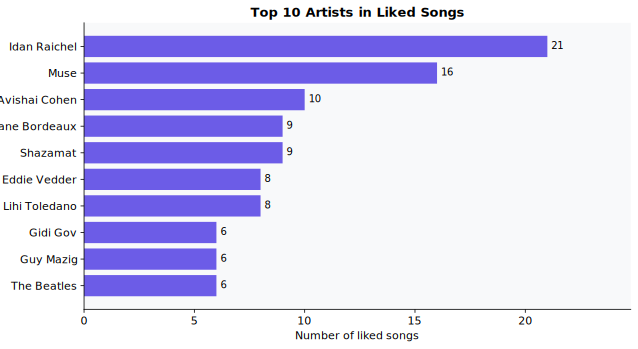

In [5]:
df = q("""
SELECT t.artist, COUNT(t.id) AS song_count
FROM tracks t
JOIN listening_snapshot ls ON t.id = ls.track_id
WHERE ls.term = 'liked'
GROUP BY t.artist
ORDER BY song_count DESC
LIMIT 10
""")
display(df)

df_s = df.sort_values('song_count')
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(df_s['artist'], df_s['song_count'], color=C1)
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel('Number of liked songs')
ax.set_title('Top 10 Artists in Liked Songs', fontsize=13, fontweight='bold')
ax.set_xlim(0, df_s['song_count'].max() * 1.18)
plt.tight_layout()
plt.show()

---
## Q5 — How many unique artists are represented across your liked songs?

,unique_artists
0,393


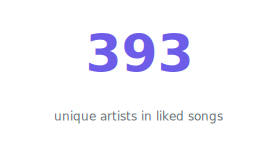

In [6]:
df = q("""
SELECT COUNT(DISTINCT t.artist) AS unique_artists
FROM tracks t
JOIN listening_snapshot ls ON t.id = ls.track_id
WHERE ls.term = 'liked'
""")
display(df)
kpi(df['unique_artists'][0], "unique artists in liked songs")

---
## Q6 — How many liked songs do you have per release decade?

,decade,song_count
0,1950s,2
1,1960s,26
2,1970s,57
3,1980s,21
4,1990s,44
5,2000s,128
6,2010s,218
7,2020s,140


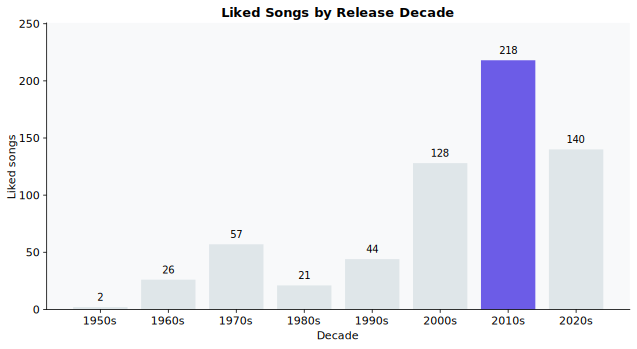

In [7]:
df = q("""
SELECT (t.release_year / 10 * 10) || 's' AS decade, COUNT(t.id) AS song_count
FROM tracks t
JOIN listening_snapshot ls ON t.id = ls.track_id
WHERE ls.term = 'liked' AND t.release_year IS NOT NULL
GROUP BY decade
ORDER BY decade
""")
display(df)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [C1 if d == '2010s' else C2 for d in df['decade']]
bars = ax.bar(df['decade'], df['song_count'], color=colors)
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel('Decade')
ax.set_ylabel('Liked songs')
ax.set_title('Liked Songs by Release Decade', fontsize=13, fontweight='bold')
ax.set_ylim(0, df['song_count'].max() * 1.15)
plt.tight_layout()
plt.show()

---
## Q7 — What are your 5 oldest liked songs?

,name,artist,release_year
0,Take Five,The Dave Brubeck Quartet,1959
1,Moanin',Art Blakey & The Jazz Messengers,1959
2,"Take the ""A"" Train",Duke Ellington,1961
3,Can't Help Falling in Love,Elvis Presley,1961
4,In A Sentimental Mood,"Duke Ellington, John Coltrane",1963


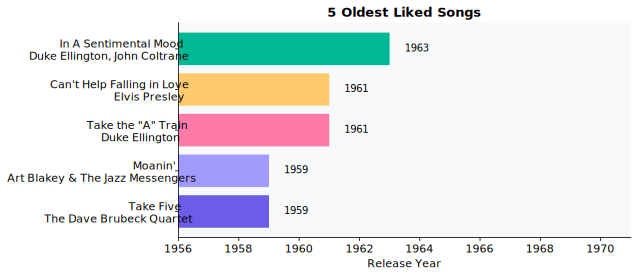

In [8]:
df = q("""
SELECT t.name, t.artist, t.release_year
FROM tracks t
JOIN listening_snapshot ls ON t.id = ls.track_id
WHERE ls.term = 'liked' AND t.release_year IS NOT NULL
ORDER BY t.release_year ASC
LIMIT 5
""")
display(df)

labels = df['name'] + '\n' + df['artist']
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels, df['release_year'], color=PALETTE[:len(df)])
ax.set_xlabel('Release Year')
ax.set_title('5 Oldest Liked Songs', fontsize=13, fontweight='bold')
ax.set_xlim(df['release_year'].min() - 3, df['release_year'].max() + 8)
for i, yr in enumerate(df['release_year']):
    ax.text(yr + 0.5, i, str(yr), va='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## Q8 — What are your 5 most recently released liked songs?

In [9]:
df = q("""
SELECT t.name, t.artist, t.release_year
FROM tracks t
JOIN listening_snapshot ls ON t.id = ls.track_id
WHERE ls.term = 'liked' AND t.release_year IS NOT NULL
ORDER BY t.release_year DESC
LIMIT 5
""")
display(df)

,name,artist,release_year
0,Your Nonsense Makes Sense,The 502s,2025
1,לפני שהכל נרדם,"Alma Gov, אבנר טואג",2025
2,סוף טוב,Yoni Bloch,2025
3,לא בכוונה,Lihi Toledano,2024
4,גן יבנה 2,Lihi Toledano,2024


---
## Q9 — What are your current top 10 short-term tracks?

In [10]:
df = q("""
SELECT ls.rank, t.name, t.artist
FROM tracks t
JOIN listening_snapshot ls ON t.id = ls.track_id
WHERE ls.term = 'short_term'
ORDER BY ls.rank
LIMIT 10
""")
display(df)

,rank,name,artist
0,1,Perach (Flower),"Stav Goldberg, Aviv Peck"
1,2,לא בכוונה,Lihi Toledano
2,3,שיר לאמא,Alon Eder
3,4,יום שישי,"Hadag Nahash, Izhak Klepter"
4,5,Gymnopédie No. 1,"Erik Satie, Philippe Entremont"
5,6,בואי נעזוב,"Elai Botner, Ran Danker"
6,7,גן יבנה 2,Lihi Toledano
7,8,Money,Pink Floyd
8,9,The Bitch Of Living - Original Broadway Cast R...,"John Gallagher Jr., Brian Johnson, Jonathan B...."
9,10,היא חזרה בתשובה,Matti Caspi


---
## Q10 — Which songs appear in ALL THREE time ranges simultaneously?

In [11]:
df = q("""
SELECT t.name, t.artist, COUNT(DISTINCT ls.term) AS term_count
FROM tracks t
JOIN listening_snapshot ls ON t.id = ls.track_id
WHERE ls.term IN ('short_term', 'medium_term', 'long_term')
GROUP BY t.id
HAVING COUNT(DISTINCT ls.term) = 3
ORDER BY t.name
""")
if df.empty:
    print("No songs appear in all three time ranges simultaneously.")
    print("Your short-term, medium-term, and long-term tastes are distinct — your music taste evolves over time!")
else:
    display(df)

No songs appear in all three time ranges simultaneously.
Your short-term, medium-term, and long-term tastes are distinct — your music taste evolves over time!


---
## Q11 — Which artists appear in BOTH short-term AND long-term top tracks?

In [12]:
df = q("""
SELECT DISTINCT t.artist
FROM tracks t
JOIN listening_snapshot ls ON t.id = ls.track_id
WHERE ls.term = 'short_term'
  AND t.artist IN (
      SELECT DISTINCT t2.artist
      FROM tracks t2
      JOIN listening_snapshot ls2 ON ls2.track_id = t2.id
      WHERE ls2.term = 'long_term'
  )
ORDER BY t.artist
""")
display(df)
print(f"\n{len(df)} artist(s) consistently appear in both recent and all-time top charts.")

,artist
0,Lihi Toledano



1 artist(s) consistently appear in both recent and all-time top charts.


---
## Q12 — Long-term top 10 tracks: which are also liked?

In [13]:
df = q("""
WITH flat AS (
    SELECT
        ls.track_id,
        CASE WHEN ls2.term = 'liked' THEN 1 ELSE 0 END AS is_liked,
        ls3.rank AS long_term_rank
    FROM (SELECT DISTINCT track_id FROM listening_snapshot) ls
    LEFT JOIN listening_snapshot ls2 ON ls2.track_id = ls.track_id AND ls2.term = 'liked'
    LEFT JOIN listening_snapshot ls3 ON ls3.track_id = ls.track_id AND ls3.term = 'long_term'
)
SELECT
    f.long_term_rank AS rank,
    t.name,
    t.artist,
    CASE WHEN f.is_liked = 1 THEN 'Yes' ELSE 'No' END AS is_liked
FROM flat f
JOIN tracks t ON t.id = f.track_id
WHERE f.long_term_rank IS NOT NULL
ORDER BY f.long_term_rank
LIMIT 10
""")
display(df)

,rank,name,artist,is_liked
0,1,זאת תל אביב,"החבדניקים, התיאטרון הקאמרי, תזמורת המהפכה, אלע...",Yes
1,2,אוברטורה,"החבדניקים, התיאטרון הקאמרי, תזמורת המהפכה",No
2,3,שיר לנטע,ניר כנען,No
3,4,אוברטורה,ניר כנען,No
4,5,אמור פו,"Roee Goor‎, Efrat Gosh",Yes
5,6,פסטה בשמנת,ניר כנען,Yes
6,7,יום מיוחד,"החבדניקים, התיאטרון הקאמרי, תזמורת המהפכה, Tal...",Yes
7,8,סווטשירטים באוגוסט,ניר כנען,No
8,9,אולי תבואי,Boaz Krauzer,Yes
9,10,Remembering,Avishai Cohen,Yes


---
## Q13 — How many short-term top tracks are NOT in your liked songs?

,also_liked,not_liked
0,10,40


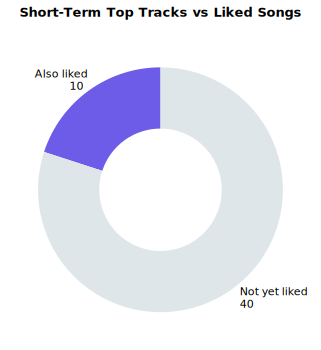

In [14]:
df = q("""
SELECT
    SUM(CASE WHEN ls2.track_id IS NOT NULL THEN 1 ELSE 0 END) AS also_liked,
    SUM(CASE WHEN ls2.track_id IS NULL     THEN 1 ELSE 0 END) AS not_liked
FROM listening_snapshot ls
LEFT JOIN listening_snapshot ls2
    ON ls2.track_id = ls.track_id AND ls2.term = 'liked'
WHERE ls.term = 'short_term'
""")
display(df)

also_liked = int(df['also_liked'][0])
not_liked  = int(df['not_liked'][0])
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [also_liked, not_liked],
    labels=[f'Also liked\n{also_liked}', f'Not yet liked\n{not_liked}'],
    colors=[C1, C2],
    startangle=90,
    wedgeprops=dict(width=0.5),
    textprops=dict(fontsize=11),
)
ax.set_title('Short-Term Top Tracks vs Liked Songs', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---
## Q14 — What are the 5 longest liked songs?

,name,artist,duration
0,Concierto De Aranjuez,Jim Hall,19:20
1,Moanin',Art Blakey & The Jazz Messengers,9:30
2,Free Bird,Lynyrd Skynyrd,9:18
3,Kashmir - Remaster,Led Zeppelin,8:37
4,American Pie,Don McLean,8:36


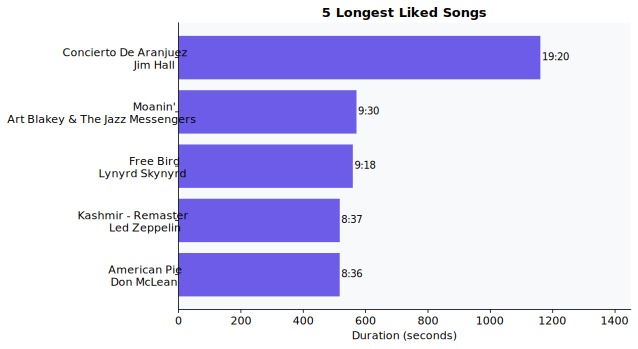

In [15]:
df = q("""
SELECT
    t.name, t.artist, t.duration_ms,
    (CAST(t.duration_ms / 60000 AS TEXT) || ':' ||
     printf('%02d', (t.duration_ms % 60000) / 1000)) AS duration
FROM tracks t
JOIN listening_snapshot ls ON ls.track_id = t.id
WHERE ls.term = 'liked' AND t.duration_ms IS NOT NULL
ORDER BY t.duration_ms DESC
LIMIT 5
""")
display(df[['name','artist','duration']])

df_s = df.sort_values('duration_ms')
labels = df_s['name'] + '\n' + df_s['artist']
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels, df_s['duration_ms'] / 1000, color=C1)
for i, (ms, dur) in enumerate(zip(df_s['duration_ms'], df_s['duration'])):
    ax.text(ms / 1000 + 5, i, dur, va='center', fontsize=10)
ax.set_xlabel('Duration (seconds)')
ax.set_title('5 Longest Liked Songs', fontsize=13, fontweight='bold')
ax.set_xlim(0, df_s['duration_ms'].max() / 1000 * 1.25)
plt.tight_layout()
plt.show()

---
## Q15 — Average song duration per release decade (liked songs)

,decade,avg_duration_sec
0,1950s,449.8
1,1960s,215.9
2,1970s,280.5
3,1980s,250.5
4,1990s,251.6
5,2000s,237.5
6,2010s,236.1
7,2020s,209.3


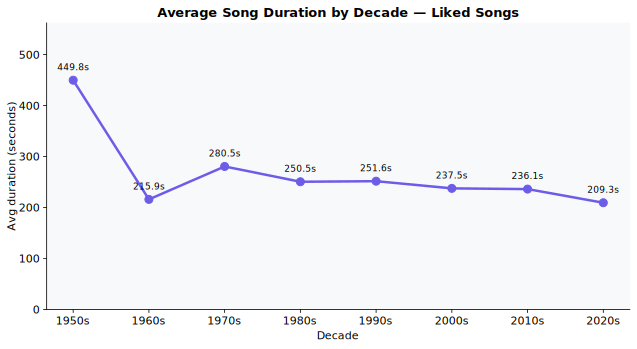

In [16]:
df = q("""
SELECT
    (t.release_year / 10 * 10) || 's' AS decade,
    ROUND(AVG(t.duration_ms) / 1000.0, 1) AS avg_duration_sec
FROM tracks t
JOIN listening_snapshot ls ON t.id = ls.track_id
WHERE ls.term = 'liked' AND t.release_year IS NOT NULL AND t.duration_ms IS NOT NULL
GROUP BY decade
ORDER BY decade
""")
display(df)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df['decade'], df['avg_duration_sec'], color=C1, marker='o', linewidth=2.5, markersize=8)
for x, y in zip(df['decade'], df['avg_duration_sec']):
    ax.annotate(f'{y}s', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
ax.set_xlabel('Decade')
ax.set_ylabel('Avg duration (seconds)')
ax.set_title('Average Song Duration by Decade — Liked Songs', fontsize=13, fontweight='bold')
ax.set_ylim(0, df['avg_duration_sec'].max() * 1.25)
plt.tight_layout()
plt.show()

---
## Q16 — Albums with the most songs in your liked list

,album,artist,song_count
0,Into The Wild (Music For The Motion Picture),Eddie Vedder,7
1,The Resistance,Muse,5
2,מי אני חושבת שאני,Lihi Toledano,5
3,בין קירות ביתי,Idan Raichel,4
4,ג'יין בורדו,Jane Bordeaux,4
5,הפרויקט של עידן רייכל,Idan Raichel,4
6,השחור החדש,Guy Mazig,4
7,שעות רגישות,Avishai Cohen,4
8,Absolution,Muse,3
9,An Awesome Wave,alt-J,3


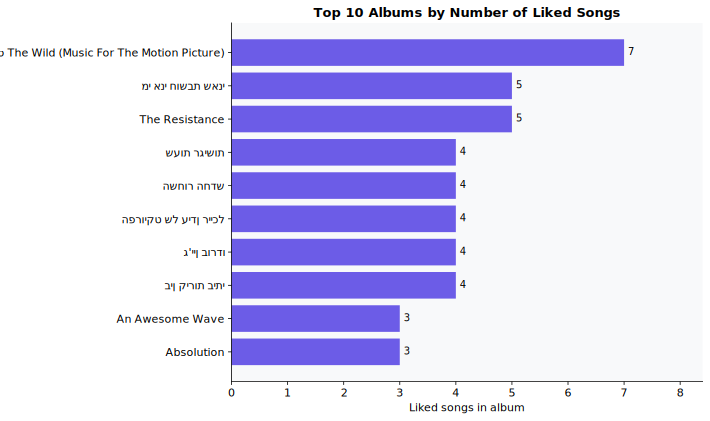

In [17]:
df = q("""
SELECT t.album, t.artist, COUNT(t.id) AS song_count
FROM tracks t
JOIN listening_snapshot ls ON t.id = ls.track_id
WHERE ls.term = 'liked' AND t.album IS NOT NULL
GROUP BY t.album, t.artist
ORDER BY song_count DESC
LIMIT 10
""")
display(df)

df_s = df.sort_values('song_count')
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_s['album'], df_s['song_count'], color=C1)
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel('Liked songs in album')
ax.set_title('Top 10 Albums by Number of Liked Songs', fontsize=13, fontweight='bold')
ax.set_xlim(0, df_s['song_count'].max() * 1.2)
plt.tight_layout()
plt.show()

---
## Q17 — Top 10 liked songs by Spotify popularity score

> **Note:** Spotify does not return popularity scores for regional / Israeli tracks. All `popularity` values in this library are `NULL`. This is a known Spotify API limitation for non-global content.

In [18]:
df = q("""
SELECT t.name, t.artist, t.popularity
FROM tracks t
JOIN listening_snapshot ls ON t.id = ls.track_id
WHERE ls.term = 'liked' AND t.popularity IS NOT NULL
ORDER BY t.popularity DESC
LIMIT 10
""")
if df.empty:
    print("No popularity data available — Spotify does not return this field for regional tracks in this library.")
else:
    display(df)

No popularity data available — Spotify does not return this field for regional tracks in this library.


---
## Q18 — Percentage of liked songs with popularity score above 50

> **Note:** Same limitation as Q17 — no popularity data available.

In [19]:
df = q("""
SELECT
    COUNT(*)  AS total_with_score,
    SUM(CASE WHEN t.popularity > 50 THEN 1 ELSE 0 END) AS above_50
FROM tracks t
JOIN listening_snapshot ls ON t.id = ls.track_id
WHERE ls.term = 'liked' AND t.popularity IS NOT NULL
""")
display(df)
print("No popularity data available — all values are NULL for this library.")

,total_with_score,above_50
0,0,None


No popularity data available — all values are NULL for this library.


---
## Q19 — Liked songs per release year (years with more than 5 songs)

,release_year,song_count
0,1967,8
1,1969,7
2,1971,8
3,1973,7
4,1975,6
5,1977,9
6,1978,6
7,1979,6
8,1983,6
9,1991,8


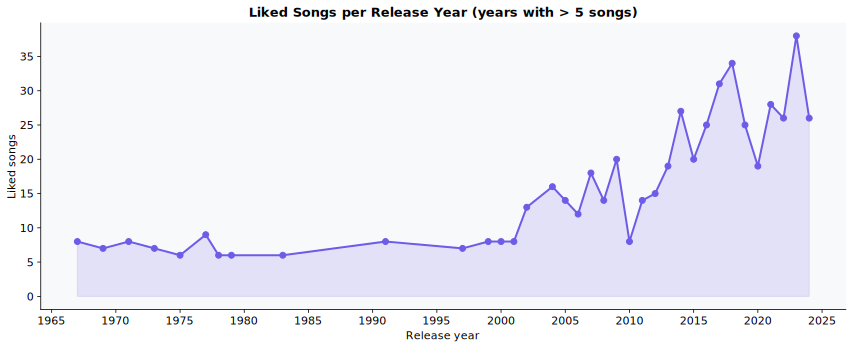

In [20]:
df = q("""
SELECT t.release_year, COUNT(t.id) AS song_count
FROM tracks t
JOIN listening_snapshot ls ON t.id = ls.track_id
WHERE ls.term = 'liked' AND t.release_year IS NOT NULL
GROUP BY t.release_year
HAVING song_count > 5
ORDER BY t.release_year
""")
display(df)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['release_year'], df['song_count'], color=C1, marker='o', linewidth=2, markersize=6)
ax.fill_between(df['release_year'], df['song_count'], alpha=0.15, color=C1)
ax.set_xlabel('Release year')
ax.set_ylabel('Liked songs')
ax.set_title('Liked Songs per Release Year  (years with > 5 songs)', fontsize=13, fontweight='bold')
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
plt.tight_layout()
plt.show()

---
## Q20 — Top 15 artists by total listening weight
*(short-term × 3, medium-term × 2, long-term × 1)*

,artist,total_weight
0,ניר כנען,15.0
1,Lihi Toledano,12.0
2,Pink Floyd,9.0
3,Jane Bordeaux,7.0
4,"Tom Misch, Yussef Dayes",6.0
5,"Stav Goldberg, Aviv Peck",5.0
6,Randy Newman,5.0
7,Matti Caspi,5.0
8,"Erik Satie, Philippe Entremont",5.0
9,"Elai Botner, Ran Danker",5.0


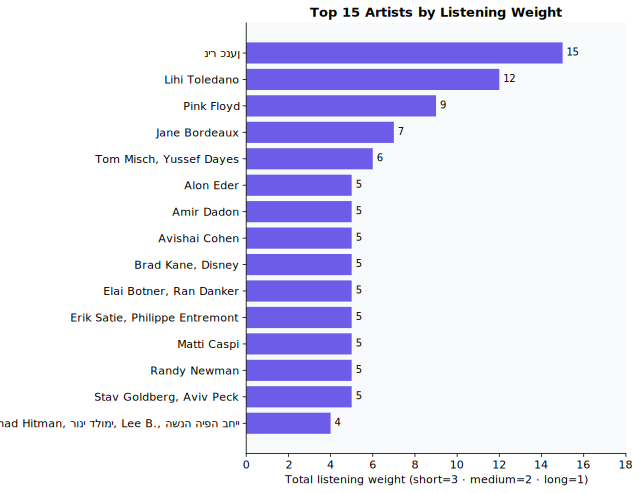

In [21]:
df = q("""
SELECT t.artist, ROUND(SUM(ls.play_weight), 0) AS total_weight
FROM tracks t
JOIN listening_snapshot ls ON t.id = ls.track_id
WHERE ls.term IN ('short_term', 'medium_term', 'long_term')
GROUP BY t.artist
ORDER BY total_weight DESC
LIMIT 15
""")
display(df)

df_s = df.sort_values('total_weight')
fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(df_s['artist'], df_s['total_weight'], color=C1)
ax.bar_label(bars, padding=4, fontsize=10, fmt='%.0f')
ax.set_xlabel('Total listening weight  (short=3 · medium=2 · long=1)')
ax.set_title('Top 15 Artists by Listening Weight', fontsize=13, fontweight='bold')
ax.set_xlim(0, df_s['total_weight'].max() * 1.2)
plt.tight_layout()
plt.show()